# gEval downstream tasks: clustering, classification, analogies

Three former notebooks merged into one. Each Part evaluates the same six RDF2Vec variants (`vanilla`, `p{1,2,3}_classic`, `p{2,3}_bound_cap16`) on a gEval downstream task, reading embeddings via `scripts/_geval.py`:

- Part 1, entity clustering (CC / CCB / CAMAP; k-means ARI). Was `geval_clustering.ipynb`.
- Part 2, entity classification (Cities, AAUP, Forbes, Metacritic; 10-fold CV accuracy). Was `geval_classification.ipynb`.
- Part 3, semantic analogies (3CosAdd top-k). Was `geval_analogies.ipynb`.

Imports and the shared variant `ORDER` live in the setup cell below; each Part declares its own `DATASETS`/`OUT`.

In [ ]:
"""Shared setup: imports, repo path, variant order. Each Part declares its own
DATASETS/OUT below its divider; all tasks read the gEval embeddings via
scripts/_geval.py.
"""
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
import numpy as np, pandas as pd, matplotlib.pyplot as plt  # noqa: E402
from scripts import _geval  # noqa: E402

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Bound family: only the norm-capped (cap16) variants are used; the no-cap
# p{1,2,3}_bound are excluded from every gEval experiment.
ORDER = ["vanilla", "p1_classic", "p2_classic", "p3_classic",
         "p2_bound_cap16", "p3_bound_cap16"]
print("variants:", ORDER)


## Part 1: entity clustering (CC / CCB / CAMAP)

Real-world counterpart to the synthetic DLCC node-classification benchmark, on
all three GEval clustering gold standards (Pellegrino et al.; MASCHInE §4.2.2):

| dataset | classes | k | regime |
|---|---|---|---|
| CC  | cities, countries | 2 | hard: both are `dbo:Place` (shared parent) |
| CCB | cities (pop≥2000), countries | 2 | hard: same shared-parent regime, cleaner city set |
| CAMAP | albums, cities, companies, movies, universities | 5 | easier: 3 distinct generic parents (`Work` / `Place` / `Agent`) |

Hypothesis (from the professor's comment): schema/concept information should
help most when the ground-truth classes share a parent and must be told apart
by fine distinctions (CC/CCB), and least when the classes are already generic
and distinct (CAMAP, where plain co-occurrence already separates them).

Protocol: k-means with `k = #clusters` on entity embeddings, scored vs gold
labels with GEval metrics (ARI, AMI, NMI, VM, FM, H, C). Only entities present in
the shared 1.28M vocab are clustered (same set across variants per dataset).

Logic: [`scripts/_geval.py`](../scripts/_geval.py).

In [ ]:
DATASETS = ["CC", "CCB", "CAMAP"]
OUT = REPO / "notebooks" / "geval_clustering"; OUT.mkdir(exist_ok=True)
print("datasets:", DATASETS, "| variants:", ORDER)


### 1. Coverage (per dataset, shared vocab)

In [2]:
vocab = _geval.load_vocab("vanilla")
cov = {ds: (_geval.coverage_report(ds, vocab)
              .assign(cluster=lambda d: d["cluster"].astype(str))
              .set_index("cluster")["coverage"])
       for ds in DATASETS}
cov_tbl = pd.DataFrame(cov)
cov_tbl

,CC,CCB,CAMAP
cluster,,,
0,0.513,0.513,0.539
1,0.831,0.826,0.817
2,NaN,NaN,0.356
3,NaN,NaN,0.967
4,NaN,NaN,0.313
ALL,0.764,0.657,0.493


Cluster `0` = countries throughout; CAMAP clusters 2 & 4 (companies, universities)
are weakly covered (about 31–36%), so read CAMAP with that caveat.

### 2. Clustering per dataset: k-means, raw vectors

In [3]:
results = {ds: _geval.evaluate(ds, variants=ORDER) for ds in DATASETS}
for ds in DATASETS:
    print(f"\n===== {ds} (k={_geval.GEVAL_K[ds]}) =====")
    print(results[ds].reindex(ORDER)[["ARI","NMI","H","C","n"]].to_string())


===== CC (k=2) =====
                 ARI   NMI     H     C        n
vanilla        0.064 0.179 0.242 0.142 8547.000
p1_classic     0.725 0.623 0.696 0.565 8547.000
p2_classic     0.709 0.609 0.684 0.549 8547.000
p3_classic     0.736 0.634 0.704 0.576 8547.000
p2_bound_cap16 0.028 0.006 0.008 0.005 8547.000
p3_bound_cap16 0.024 0.006 0.007 0.005 8547.000

===== CCB (k=2) =====
                 ARI   NMI     H     C        n
vanilla        0.694 0.637 0.643 0.631 2853.000
p1_classic     0.856 0.799 0.804 0.794 2853.000
p2_classic     0.854 0.798 0.803 0.792 2853.000
p3_classic     0.853 0.796 0.801 0.791 2853.000
p2_bound_cap16 0.020 0.010 0.010 0.010 2853.000
p3_bound_cap16 0.018 0.009 0.009 0.009 2853.000

===== CAMAP (k=5) =====
                 ARI   NMI     H     C        n
vanilla        0.783 0.791 0.782 0.800 3133.000
p1_classic     0.785 0.800 0.814 0.787 3133.000
p2_classic     0.876 0.861 0.876 0.847 3133.000
p3_classic     0.811 0.830 0.844 0.817 3133.000
p2_bound_cap16 0.4

### 3. Summary: ARI by variant × dataset

In [4]:
ari = pd.DataFrame({ds: results[ds]["ARI"] for ds in DATASETS}).reindex(ORDER)
ari.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None).format("{:.3f}")

,CC,CCB,CAMAP
vanilla,0.064,0.694,0.783
p1_classic,0.725,0.856,0.785
p2_classic,0.709,0.854,0.876
p3_classic,0.736,0.853,0.811
p2_bound_cap16,0.028,0.020,0.404
p3_bound_cap16,0.024,0.018,0.461


### 4. Grouped bar: ARI by variant × dataset

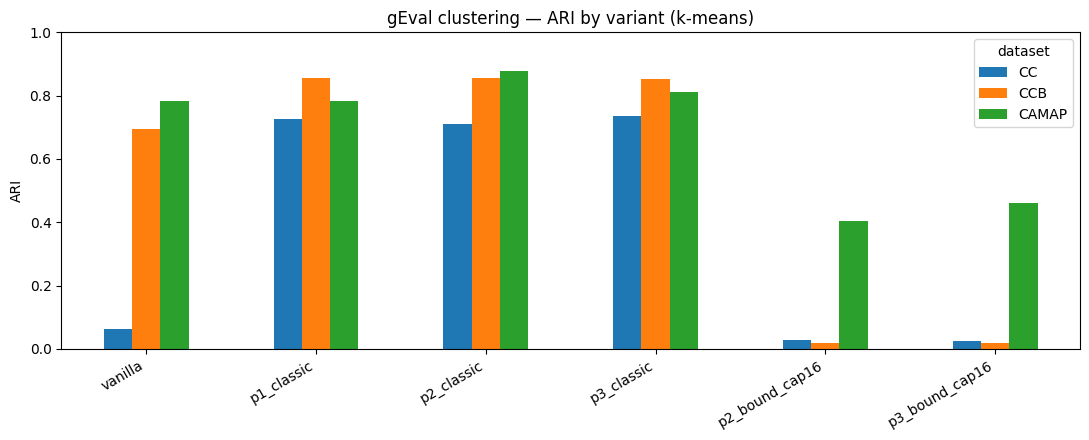

In [5]:
ax = ari.plot.bar(figsize=(11, 4.5))
ax.set_title("gEval clustering — ARI by variant (k-means)")
ax.set_ylabel("ARI"); ax.set_ylim(0, 1)
ax.legend(title="dataset"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(OUT / "geval_ari_by_variant.png", dpi=120); plt.show()

### Takeaways

The MASCHInE class-mean init (`*_classic`) is the consistent winner on real-world
clustering: CC about 0.72–0.74, CCB about 0.85, CAMAP about 0.81–0.88, best (or
tied-best) on every dataset. This is the paper's P1/P2 over V result, reproduced in
our RDF2Vec setup, and `p3_classic` is the strongest on CC at 0.736.

Schema init helps most where the hypothesis predicts. On the shared-parent tasks
(CC/CCB) the gap over `vanilla` is large (CC: about 0.72 vs 0.06). On CAMAP, where
the five classes have distinct generic parents, `vanilla` already reaches 0.78 and
classic adds only a modest lift; schema matters less when co-occurrence alone
already separates the classes.

The capped bound (`*_bound_cap16`) does not cluster. It sits at the vanilla floor
on the shared-parent tasks (CC/CCB ARI about 0.02) and only partially recovers on
the easier CAMAP (about 0.40–0.46, still below classic and vanilla). The geometry
the bound init builds is hostile to k-means, even after the norm cap that made it
the DLCC winner. This is the clearest "DLCC ≠ gEval" signal on clustering.

This bound-cap collapse is specific to clustering. On classification, regression
and (partly) analogies the same `*_bound_cap16` becomes competitive once a model,
not raw k-means geometry, does the separating. See [[dbpedia-schema-projection-plot]]
and the classification / regression / analogy notebooks.

All rows here are finetuned (epoch 5). The init-only (frozen, epoch-0) row will say
whether class-mean init already separates these classes or whether finetuning
creates the separation.

## Part 2: entity classification

The supervised GEval task (Pellegrino et al.; MASCHInE §4.2): use each entity's
embedding as features to predict a categorical label, scored by accuracy under
10-fold stratified CV. Complements the unsupervised clustering view in Part 1.

| dataset | entity type | label |
|---|---|---|
| Cities | cities | quality-of-living class (high/medium/low) |
| AAUP | universities | salary class |
| Forbes | companies | revenue class |
| MetacriticAlbums | albums | critic-score class (good/bad) |
| MetacriticMovies | movies | critic-score class (good/bad) |

Classifier panel (GEval-style): Naive Bayes, k-NN (k=3), C4.5 decision tree,
linear SVM. We report mean CV accuracy per classifier plus their average. Only
entities present in the shared 1.28M-key vocab are usable (the rest are GEval's
ignored data); classes too small to stratify are dropped.

Gold files: `evaluation_framework/Classification/data/*.tsv` → `v1/geval/classification/`.
Logic: [`scripts/_geval.py`](../scripts/_geval.py).

In [ ]:
DATASETS = ["Cities", "AAUP", "Forbes", "MetacriticAlbums", "MetacriticMovies"]
OUT = REPO / "notebooks" / "geval_classification"; OUT.mkdir(exist_ok=True)
print("datasets:", DATASETS, "| classifiers:", list(_geval.CLASSIFIERS))


### 1. Coverage (per dataset, shared vocab)

How many gold entities exist in our embedding vocab. All variants share one
vocab, so coverage is identical across variants, checked once.

In [2]:
vocab = _geval.load_vocab("vanilla")
cov = {ds: (_geval.classification_coverage(ds, vocab)
              .set_index("label")["coverage"]) for ds in DATASETS}
pd.DataFrame(cov)

,Cities,AAUP,Forbes,MetacriticAlbums,MetacriticMovies
label,,,,,
ALL,0.868,0.796,0.250,0.358,0.539
bad,NaN,NaN,NaN,0.431,0.531
good,NaN,NaN,NaN,0.285,0.548
high,0.910,0.944,0.636,NaN,NaN
low,0.821,0.606,0.176,NaN,NaN
medium,0.858,0.825,0.287,NaN,NaN


### 2. Classification per dataset: 10-fold CV accuracy, raw vectors

One row per variant; columns are the classifier panel plus their `mean`. `n` =
entities used after coverage and stratifiability filtering.

In [3]:
results = {ds: _geval.evaluate_classification(ds, variants=ORDER) for ds in DATASETS}
for ds in DATASETS:
    print(f"\n===== {ds} =====")
    print(results[ds].reindex(ORDER)[list(_geval.CLASSIFIERS)+["mean","n"]].to_string())


===== Cities =====
                  NB   KNN  C4.5   SVM  mean       n
vanilla        0.781 0.656 0.527 0.765 0.682 184.000
p1_classic     0.684 0.646 0.516 0.701 0.637 184.000
p2_classic     0.695 0.668 0.653 0.749 0.691 184.000
p3_classic     0.656 0.673 0.558 0.706 0.648 184.000
p2_bound_cap16 0.554 0.662 0.536 0.732 0.621 184.000
p3_bound_cap16 0.505 0.640 0.598 0.706 0.612 184.000

===== AAUP =====
                  NB   KNN  C4.5   SVM  mean       n
vanilla        0.543 0.547 0.544 0.630 0.566 764.000
p1_classic     0.420 0.611 0.555 0.677 0.566 764.000
p2_classic     0.480 0.617 0.512 0.683 0.573 764.000
p3_classic     0.480 0.581 0.550 0.664 0.569 764.000
p2_bound_cap16 0.628 0.631 0.614 0.682 0.639 764.000
p3_bound_cap16 0.595 0.590 0.564 0.682 0.608 764.000

===== Forbes =====
                  NB   KNN  C4.5   SVM  mean       n
vanilla        0.402 0.462 0.437 0.561 0.465 396.000
p1_classic     0.326 0.475 0.447 0.558 0.451 396.000
p2_classic     0.361 0.467 0.434 0.573 0.

### 3. Summary: mean accuracy by variant × dataset

In [4]:
acc = pd.DataFrame({ds: results[ds]["mean"] for ds in DATASETS}).reindex(ORDER)
acc.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None).format("{:.3f}")

,Cities,AAUP,Forbes,MetacriticAlbums,MetacriticMovies
vanilla,0.682,0.566,0.465,0.565,0.657
p1_classic,0.637,0.566,0.451,0.569,0.615
p2_classic,0.691,0.573,0.459,0.563,0.631
p3_classic,0.648,0.569,0.471,0.578,0.623
p2_bound_cap16,0.621,0.639,0.489,0.562,0.642
p3_bound_cap16,0.612,0.608,0.479,0.560,0.643


### 4. Grouped bar: mean accuracy by variant × dataset

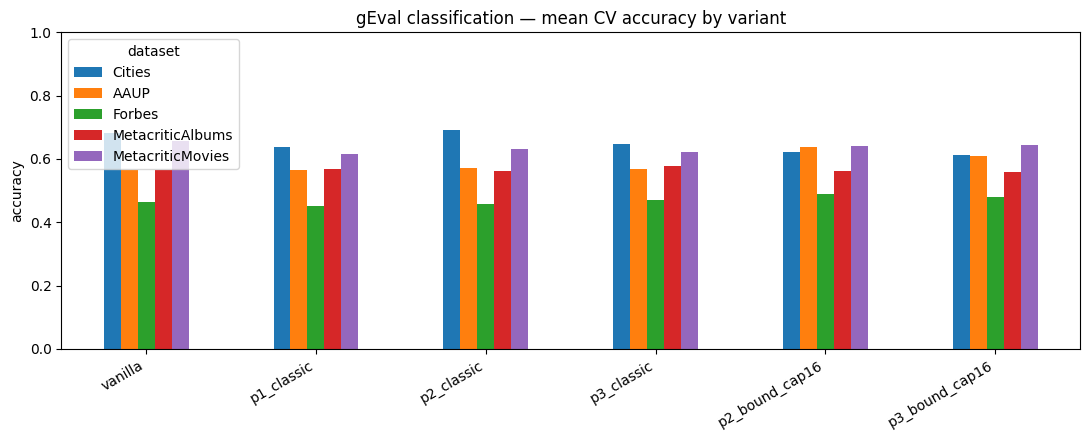

In [5]:
ax = acc.plot.bar(figsize=(11, 4.5))
ax.set_title("gEval classification — mean CV accuracy by variant")
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
ax.legend(title="dataset"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(OUT / "geval_acc_by_variant.png", dpi=120); plt.show()

### Takeaways

Classification tells a different story from clustering, and that contrast is the
result.

Supervised classification flattens the variants. Mean accuracy sits in a narrow
band (about 0.46–0.69) and no variant dominates: the large `*_classic` over
`vanilla` gap that defined clustering (CC: 0.72 vs 0.06) is gone. A fitted decision
boundary (NB/KNN/C4.5/SVM) extracts class signal that raw k-means geometry could
not, so the init's head start matters far less.

`vanilla` is competitive, and best on some datasets (Cities 0.682, MetacriticMovies
0.657). Concept init no longer buys a consistent edge once a classifier does the
separating.

The capped bound, which collapses on clustering, is competitive here.
`*_bound_cap16` is the best variant on AAUP (0.639) and Forbes (0.489), and on
MetacriticMovies it has the single best classifier (SVM 0.737 vs vanilla 0.689)
though vanilla edges it on the mean. The geometry the bound init produces is hostile
to k-means but usable by a supervised model, so "good embedding" is task-relative.

`*_classic` only marginally leads where labels track ontology class (Cities 0.691
via p2, AAUP 0.573). Where labels are critic scores / revenue (weakly tied to
schema) it has no advantage, and on MetacriticMovies it is the worst family.

Clustering and classification probe different things: clustering rewards init
geometry; classification rewards separability a model can fit. The schema-init story
is strong on the former and washes out on the latter, so report both and scope the
claim.

## Part 3: semantic analogies

A purely geometric GEval task, no classifier, no CV. Each line is a quadruplet
`(a, b, c, d)` of DBpedia entities; we predict `d` by 3CosAdd: the nearest
neighbour (cosine) to `b - a + c` over the full 1.28M vocab, excluding `a/b/c`.
Scored by top-k accuracy. Mirrors GEval's `semanticAnalogies_model.py`.

| dataset | relation tested | example (a:c :: b:d) |
|---|---|---|
| capital_country | capital → country | Athens:Greece :: Baghdad:Iraq |
| all_capital_country | capital → country (larger) | " |
| currency | country → currency | Algeria:Dinar :: Angola:Kwanza |
| city_state | US city → US state | Chicago:Illinois :: Houston:Texas |

This probes whether relational structure survived in the space, a different
question from clustering/classification (which probe class separability). It is
also a hard top-1 test: the answer must beat all 1.28M vocab entries.

Gold: `evaluation_framework/SemanticAnalogies/data/*.txt` → `v1/geval/analogies/`.
Logic: [`scripts/_geval.py`](../scripts/_geval.py).

In [ ]:
DATASETS = list(_geval.ANALOGY_DATASETS)
OUT = REPO / "notebooks" / "geval_analogies"; OUT.mkdir(exist_ok=True)
print("datasets:", DATASETS)


### 1. Coverage: fully-answerable quadruplets (all 4 URIs in vocab)

A quad is only scorable if `a`, `b`, `c` and `d` are all in the shared vocab.
Same vocab across variants, so checked once.

In [2]:
vocab = _geval.load_vocab("vanilla")
pd.DataFrame([_geval.analogy_coverage(ds, vocab) for ds in DATASETS]).set_index("dataset")

,total,answerable,coverage
dataset,,,
capital_country,506,506,1.000
all_capital_country,4524,4139,0.915
currency,866,598,0.691
city_state,2467,1935,0.784


### 2. Top-k accuracy per dataset (3CosAdd, full-vocab nearest neighbour)

`n` = scorable quadruplets. This cell does a full-vocab NN search per quad per
variant, so it is the slowest notebook (a few minutes).

In [3]:
results = {ds: _geval.evaluate_analogies(ds, variants=ORDER) for ds in DATASETS}
for ds in DATASETS:
    print(f"\n===== {ds} =====")
    print(results[ds].reindex(ORDER)[["top1","top2","n"]].to_string())


===== capital_country =====
                top1  top2       n
vanilla        0.676 0.769 506.000
p1_classic     0.802 0.877 506.000
p2_classic     0.832 0.911 506.000
p3_classic     0.866 0.933 506.000
p2_bound_cap16 0.709 0.771 506.000
p3_bound_cap16 0.650 0.719 506.000

===== all_capital_country =====
                top1  top2        n
vanilla        0.721 0.795 4139.000
p1_classic     0.491 0.544 4139.000
p2_classic     0.487 0.557 4139.000
p3_classic     0.495 0.560 4139.000
p2_bound_cap16 0.256 0.322 4139.000
p3_bound_cap16 0.244 0.317 4139.000

===== currency =====
                top1  top2       n
vanilla        0.579 0.607 598.000
p1_classic     0.321 0.356 598.000
p2_classic     0.365 0.396 598.000
p3_classic     0.299 0.343 598.000
p2_bound_cap16 0.472 0.528 598.000
p3_bound_cap16 0.457 0.498 598.000

===== city_state =====
                top1  top2        n
vanilla        0.152 0.270 1935.000
p1_classic     0.321 0.391 1935.000
p2_classic     0.304 0.382 1935.000
p3_cla

### 3. Summary: top-1 accuracy by variant × dataset

In [4]:
top1 = pd.DataFrame({ds: results[ds]["top1"] for ds in DATASETS}).reindex(ORDER)
top1.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None).format("{:.3f}")

,capital_country,all_capital_country,currency,city_state
vanilla,0.676,0.721,0.579,0.152
p1_classic,0.802,0.491,0.321,0.321
p2_classic,0.832,0.487,0.365,0.304
p3_classic,0.866,0.495,0.299,0.307
p2_bound_cap16,0.709,0.256,0.472,0.230
p3_bound_cap16,0.650,0.244,0.457,0.232


### 4. Grouped bar: top-1 accuracy by variant × dataset

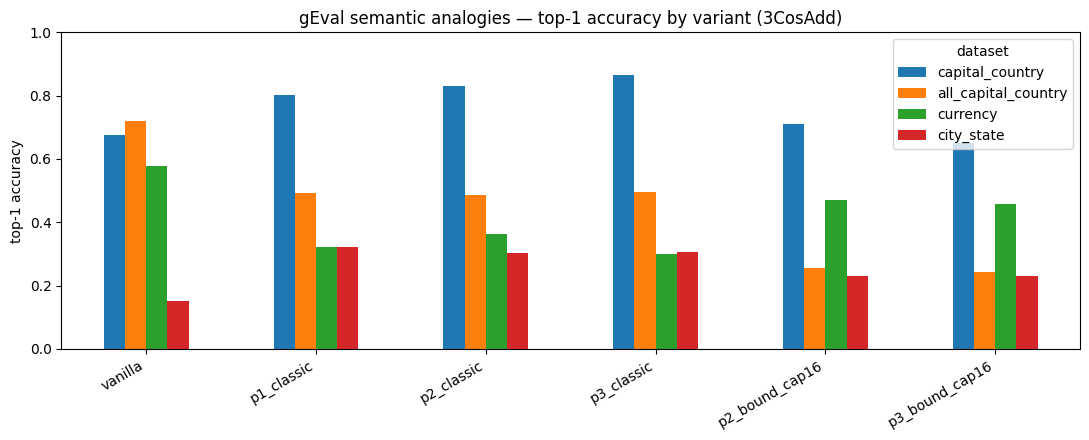

In [5]:
ax = top1.plot.bar(figsize=(11, 4.5))
ax.set_title("gEval semantic analogies — top-1 accuracy by variant (3CosAdd)")
ax.set_ylabel("top-1 accuracy"); ax.set_ylim(0, 1)
ax.legend(title="dataset"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(OUT / "geval_analogy_top1.png", dpi=120); plt.show()

### Takeaways

Analogies give a third, distinct pattern, neither the clustering result nor the
classification/regression result. There is no consistent winner: `classic` wins two
datasets, `vanilla` the other two, and `cap16` sits in between.

`classic` vs `vanilla` flips with answer-set scale. On the small capital_country
(506) and on city_state, class-mean init wins clearly (p3_classic 0.866 vs vanilla
0.676; classic about 0.31 vs vanilla 0.152). But on the large all_capital_country
(4139) and currency, `vanilla` wins decisively (0.721 vs classic about 0.49; 0.579
vs classic about 0.33). A plausible mechanism: class-mean init pulls every country
toward a shared "country" centroid, good for coarse separation but it blurs the
within-class identity 3CosAdd needs to retrieve one specific country out of
hundreds. vanilla keeps co-occurrence-specific positions.

The capped bound is a genuine middle performer here, not the floor it is on
clustering. `*_bound_cap16` beats `vanilla` on capital_country (0.709 vs 0.676) and
lands second on currency and city_state. Analogies are far more forgiving of bound
geometry than k-means clustering, where cap16 stays pinned at the vanilla floor
(CC/CCB ARI about 0.02).

Reading across all four tasks: clustering rewards class-mean init and floors the
bound-cap; classification and regression flatten everyone and let bound-cap compete;
analogies reward class-mean init only at small answer-set scale and rank bound-cap in
the middle. No single variant is best; the right embedding is task- and
scale-relative. This is the strongest multi-task evidence that the DLCC ranking does
not transfer.